In [ ]:
from matplotlib import pyplot as plt
from math import log2
import numpy as np
import matplotlib as mpl


In [119]:
data = np.array([
[240, 2],
[60, 2],
[170, 0],
[340, 0],
[240, 2],
[85, 2],
[85, 2],
[120, 2],
[120, 2],
[120, 2],
[240, 2],
[170, 0],
[120, 4],
[240, 2],
[240, 0],
[340, 0],
[240, 2],
[60, 2],
[240, 2],
[120, 2],
[240, 2],
[85, 2],
[60, 2],
[340, 0],
[60, 2],
[240, 2],
[60, 2],
[340, 0],
[85, 2],
[60, 2],
[170, 0],
[340, 0],
[170, 2],
[60, 2],
[120, 2],
[60, 2],
[85, 2],
[120, 2],
[120, 2],
[60, 2],
[170, 0],
[340, 0],
[170, 2],
[240, 2],
[340, 0],
[85, 2],
[170, 0],
[170, 0],
[340, 0],
[85, 2],
[340, 0],
[85, 2],
[120, 2],
[170, 0],
[60, 2],
[340, 0],
[85, 2],
[85, 2],
[170, 0],
[120, 2],
])
np.save('../../out/edge/data.mqlib.k61', data)

In [120]:
dwave_data_k101 = np.load('../../out/edge/data.dwave.k101.npy')
dwave_data_k201 = np.load('../../out/edge/data.dwave.k201.npy')

mqlib_data_k41 = np.load('../../out/edge/data.mqlib.k41.npy')
mqlib_data_k51 = np.load('../../out/edge/data.mqlib.k51.npy')
mqlib_data_k61 = np.load('../../out/edge/data.mqlib.k61.npy')
mqlib_data_k71 = np.load('../../out/edge/data.mqlib.k71.npy')
mqlib_data_k101 = np.load('../../out/edge/data.mqlib.k101.npy')

gurobi_data_k101 = np.load('../../out/edge/data.gurobi.k101.npy')

In [121]:
mqlib_data_k61 = np.array(sorted(mqlib_data_k61, key=lambda e: e[0]))
np.save('../../out/edge/data.mqlib.k61', mqlib_data_k61)

In [ ]:
times, counts = np.unique(mqlib_data_k51[:,0], return_counts=True)
print(times, counts)

In [118]:
data, counts = np.unique(mqlib_data_k71, return_counts=True)
print(data, counts)
print(mqlib_data_k61)

[  0   2  60  85 120 170 240] [31 19 10 10 10 10 10]
[[ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 60   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [ 85   2]
 [120   2]
 [120   2]
 [120   2]
 [120   4]
 [120   2]
 [120   2]
 [120   2]
 [120   2]
 [120   2]
 [120   2]
 [170   0]
 [170   0]
 [170   0]
 [170   2]
 [170   0]
 [170   2]
 [170   0]
 [170   0]
 [170   0]
 [170   0]
 [240   2]
 [240   2]
 [240   2]
 [240   2]
 [240   0]
 [240   2]
 [240   2]
 [240   2]
 [240   2]
 [240   2]]


In [ ]:
def compare_solvers(*args):
    fig, ax = plt.subplots()
    
    colours = ['tab:blue', 'tab:orange', 'tab:green']
    names = ['D-Wave', 'Gurobi', 'MQLib']
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data, return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(unique_data[:, 0] / 60, unique_data[:, 1], s=marker_sizes, c=colours[idx], label=names[idx], alpha=0.5)
        
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), labelspacing=3)
    ax.grid(True, which="both", axis='y')
    fig.tight_layout()
    plt.show()

In [86]:
def compare_problem_sizes(*args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    
    markers = ['o', 'x', 's', 'v']
    
    kmer_sizes = [arg[0] for arg in args]
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data[1], return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(
            np.round(unique_data[:, 0] / 60, 1), unique_data[:, 1], 
            s=marker_sizes, color=colours[idx], label=kmer_sizes[idx], alpha=0.5, marker=markers[idx]
        )
    
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), title='k')
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

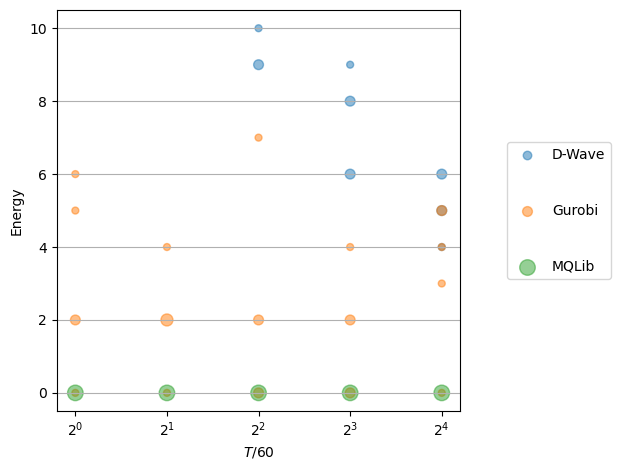

In [103]:
compare_solvers(dwave_data_k101, gurobi_data_k101, mqlib_data_k101)

In [ ]:
compare_solvers(dwave_data_k201)

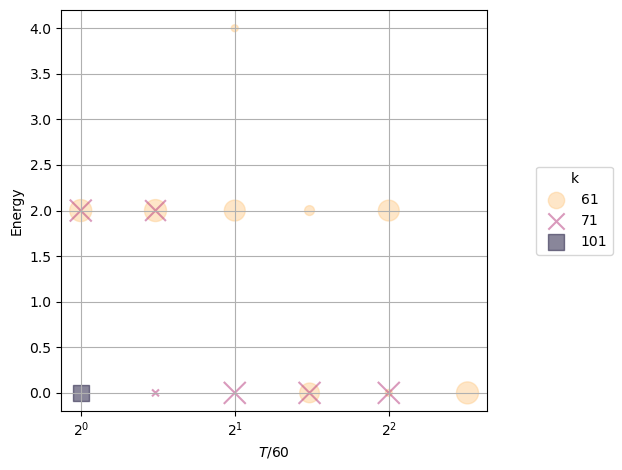

In [122]:
compare_problem_sizes(
    (61, mqlib_data_k61), 
    (71, mqlib_data_k71), 
    (101, mqlib_data_k101[0:5,:]),
)

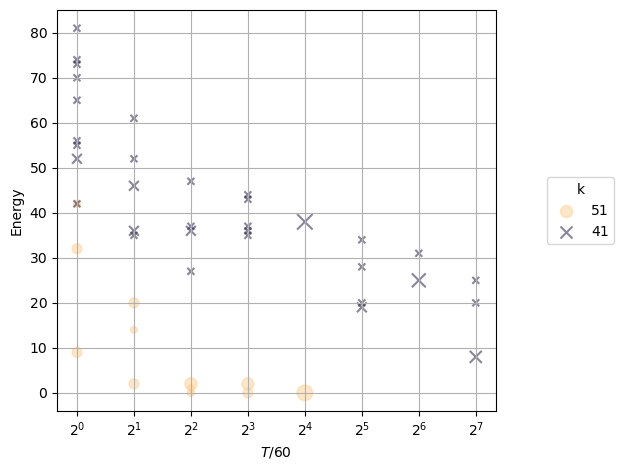

In [95]:
compare_problem_sizes(
    (51, mqlib_data_k51),
    (41, mqlib_data_k41)
)

In [97]:
2 ** 1.5 * 60

169.7056274847714